# EDA - Hệ Thống Gợi Ý Cây Trồng

**Cấu trúc:**
1. Tổng quan dữ liệu
2. Phân tích đơn biến
3. Phân tích hai biến
4. Phân tích đa biến

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/raw/Crop_recommendation.csv'
df = pd.read_csv(DATA_PATH)
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET = 'label'
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


---
## 1. Tổng Quan Dữ Liệu

### 1.1 Phân Tích Thống Kê

In [2]:
print("=== SHAPE ===")
print(f"Số mẫu: {df.shape[0]}, Số cột: {df.shape[1]}")
print()
print("=== KIỂU DỮ LIỆU ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()
print("=== DÒNG TRÙNG LẶP ===")
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")

=== SHAPE ===
Số mẫu: 2200, Số cột: 8

=== KIỂU DỮ LIỆU ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

=== MISSING VALUES ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== DÒNG TRÙNG LẶP ===
Số dòng trùng lặp: 0


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000
P,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000
K,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560


In [4]:
print("=== PHÂN PHỐI NHÃN ===")
print(df[TARGET].value_counts())

=== PHÂN PHỐI NHÃN ===
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### 1.2 Trực Quan Hóa — Phân Phối Nhãn

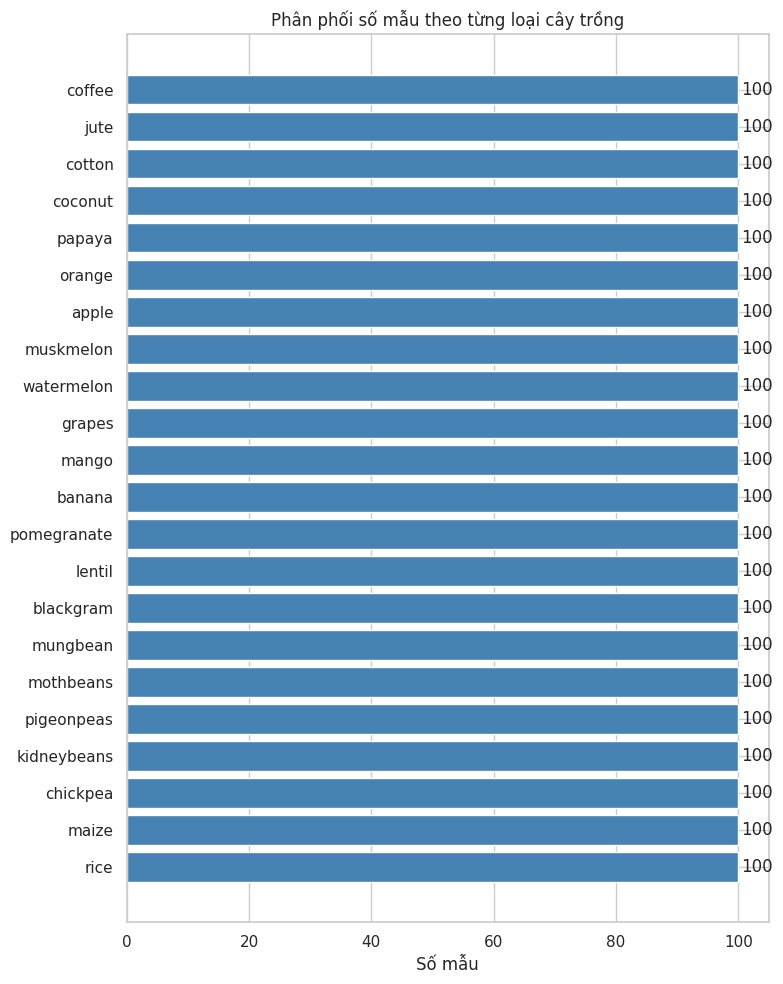

In [5]:
fig, ax = plt.subplots(figsize=(8, 10))
counts = df[TARGET].value_counts().sort_values()
ax.barh(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Số mẫu')
ax.set_title('Phân phối số mẫu theo từng loại cây trồng')
for i, v in enumerate(counts.values):
    ax.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Dataset hoàn toàn **cân bằng** (balanced): mỗi trong 22 loại cây có đúng **100 mẫu**.
- Không có hiện tượng class imbalance.

**Hướng xử lý:**
- Không cần oversampling/undersampling.
- Khi chia tập dữ liệu, dùng `stratify=label` để đảm bảo tỷ lệ đồng đều.

---
## 2. Phân Tích Đơn Biến (Univariate)

### 2.1 Phân Tích Thống Kê

In [6]:
print("=== SKEWNESS (độ lệch) ===")
print(df[FEATURES].skew().round(3))
print()
print("=== KURTOSIS (độ nhọn) ===")
print(df[FEATURES].kurt().round(3))

=== SKEWNESS (độ lệch) ===
N              0.510
P              1.011
K              2.375
temperature    0.185
humidity      -1.092
ph             0.284
rainfall       0.966
dtype: float64

=== KURTOSIS (độ nhọn) ===
N             -1.058
P              0.860
K              4.449
temperature    1.233
humidity       0.302
ph             1.656
rainfall       0.607
dtype: float64


### 2.2 Trực Quan Hóa — Histogram + KDE

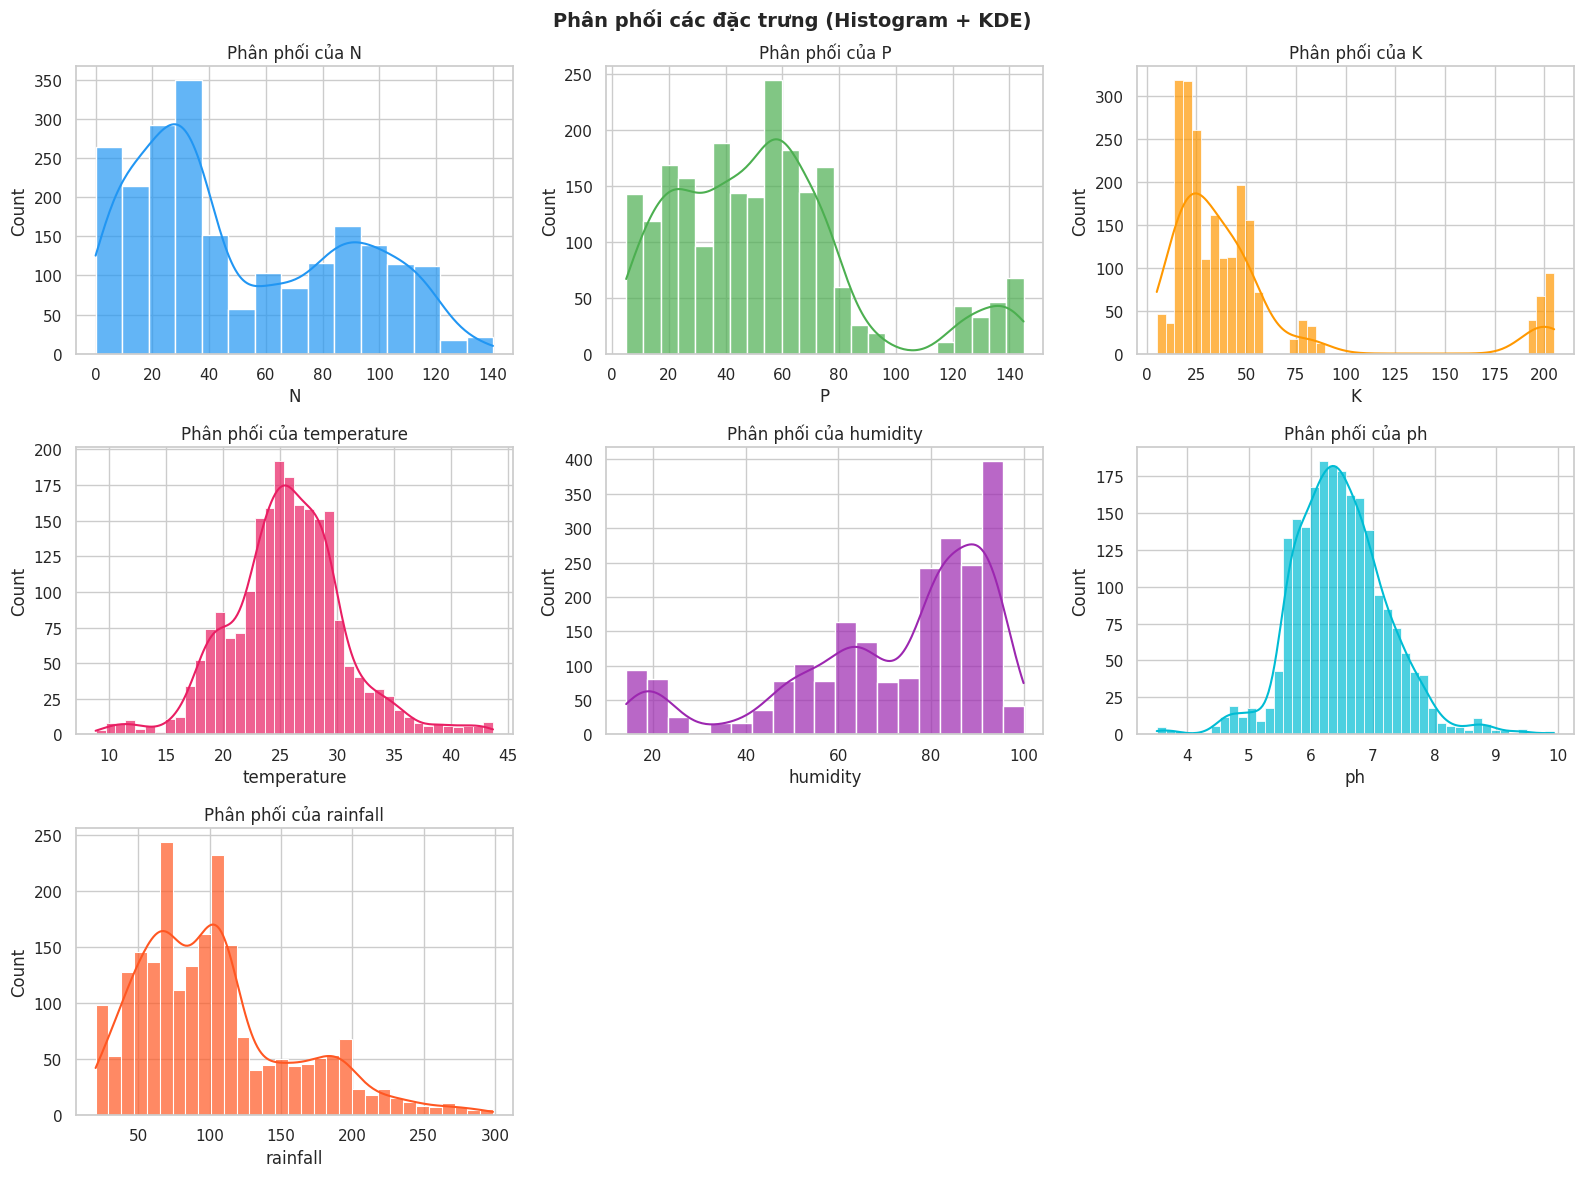

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4','#FF5722']
for i, (col, color) in enumerate(zip(FEATURES, colors)):
    sns.histplot(df[col], kde=True, ax=axes[i], color=color, alpha=0.7)
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_xlabel(col)
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các đặc trưng (Histogram + KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **N, P**: Lệch phải (right-skewed), phân phối bimodal → 2 nhóm nhu cầu dinh dưỡng khác nhau.
- **K**: Lệch phải mạnh, đuôi dài → outlier cao từ nhóm đậu đỗ.
- **Temperature**: Gần phân phối chuẩn, tập trung 20–30°C.
- **Humidity**: Bimodal rõ rệt: nhóm ~30% (cây khô) và ~85% (cây ẩm).
- **pH**: Gần chuẩn, tập trung quanh 6–7.
- **Rainfall**: Lệch phải mạnh, có outlier >250mm.

**Hướng xử lý:**
- Dùng **RobustScaler** (median & IQR) thay StandardScaler để chịu được phân phối lệch.
- Thêm feature `log_rainfall = log(1 + rainfall)` để giảm độ lệch.

### 2.3 Trực Quan Hóa — Boxplot Tổng Thể (Outlier Detection)

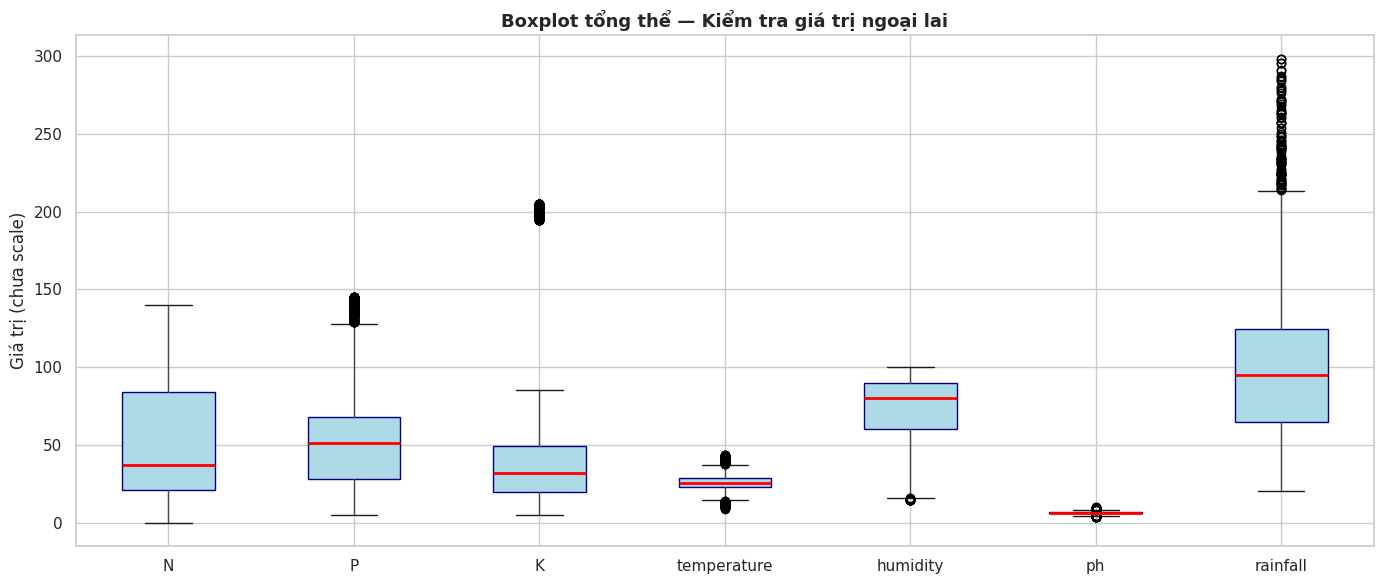

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
df[FEATURES].boxplot(ax=ax, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2))
ax.set_title('Boxplot tổng thể — Kiểm tra giá trị ngoại lai', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị (chưa scale)')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **K** có nhiều outlier phía trên → đây là giá trị **tự nhiên** của nhóm đậu đỗ (chickpea, lentil, pigeonpeas), không phải lỗi dữ liệu.
- **Rainfall** có outlier trên (>250mm) thuộc rice, papaya, coconut — cũng là tự nhiên.
- **N, P** ít outlier hơn.
- **Temperature, pH** ổn định nhất, ít outlier.

**Hướng xử lý:**
- **Không xóa outlier** vì là giá trị đặc trưng thực của từng nhóm cây.
- Áp dụng **QuantileClipper [1%, 99%]** để giảm ảnh hưởng cực biên mà không mất thông tin.

---
## 3. Phân Tích Hai Biến (Bivariate)

Phân tích mối quan hệ giữa **từng feature** và **nhãn (label)**.

### 3.1 Phân Tích Thống Kê

In [9]:
print("=== GIÁ TRỊ TRUNG BÌNH THEO TỪNG LOẠI CÂY ===")
df.groupby(TARGET)[FEATURES].mean().round(2)

=== GIÁ TRỊ TRUNG BÌNH THEO TỪNG LOẠI CÂY ===


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


In [10]:
from scipy import stats
print("=== ANOVA F-STATISTIC (khả năng phân biệt của từng feature) ===")
for col in FEATURES:
    groups = [group[col].values for _, group in df.groupby(TARGET)]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{col:15s}: F={f_stat:.1f}, p={p_val:.2e} {'*** Rất mạnh' if p_val < 0.001 else ''}")

=== ANOVA F-STATISTIC (khả năng phân biệt của từng feature) ===
N              : F=897.6, p=0.00e+00 *** Rất mạnh
P              : F=1885.7, p=0.00e+00 *** Rất mạnh
K              : F=27238.4, p=0.00e+00 *** Rất mạnh
temperature    : F=102.2, p=3.21e-305 *** Rất mạnh
humidity       : F=3103.7, p=0.00e+00 *** Rất mạnh
ph             : F=60.3, p=6.49e-199 *** Rất mạnh
rainfall       : F=605.5, p=0.00e+00 *** Rất mạnh


### 3.2 Trực Quan Hóa — Boxplot N, P, K theo Label

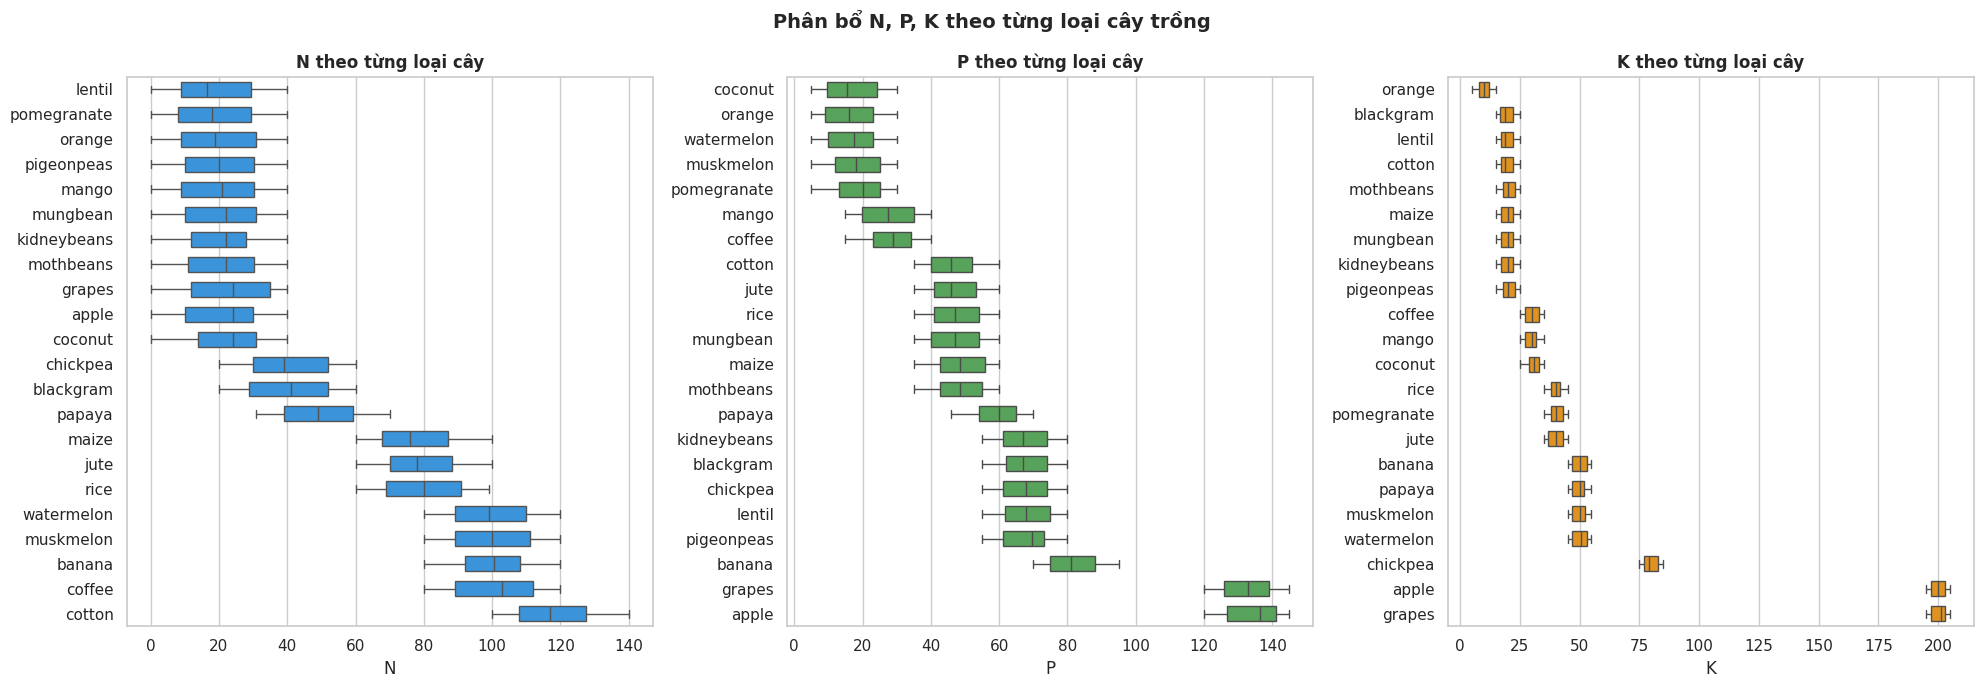

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, col, color in zip(axes, ['N', 'P', 'K'], ['#2196F3','#4CAF50','#FF9800']):
    order = df.groupby(TARGET)[col].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, color=color, width=0.6)
    ax.set_title(f'{col} theo từng loại cây', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('')
plt.suptitle('Phân bổ N, P, K theo từng loại cây trồng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **N**: Rice, Jute, Coffee cần N cao. Chickpea, Lentil, Pigeonpeas cần N thấp → N **phân biệt tốt** nhóm lúa/cà phê với nhóm đậu đỗ.
- **P & K**: Chickpea, Lentil, Pigeonpeas, Kidneybeans, Mothbeans có P và K **rất cao** (~130 và >150) — "dấu vân tay" đặc trưng của nhóm **legumes** (đậu đỗ).

**Hướng xử lý:**
- Giữ nguyên N, P, K.
- Thêm `total_npk = N + P + K` và các **ratio features**: `N/P`, `N/K`, `P/K` để mô hình nắm mối quan hệ tương đối.

### 3.3 Trực Quan Hóa — Boxplot Rainfall theo Label

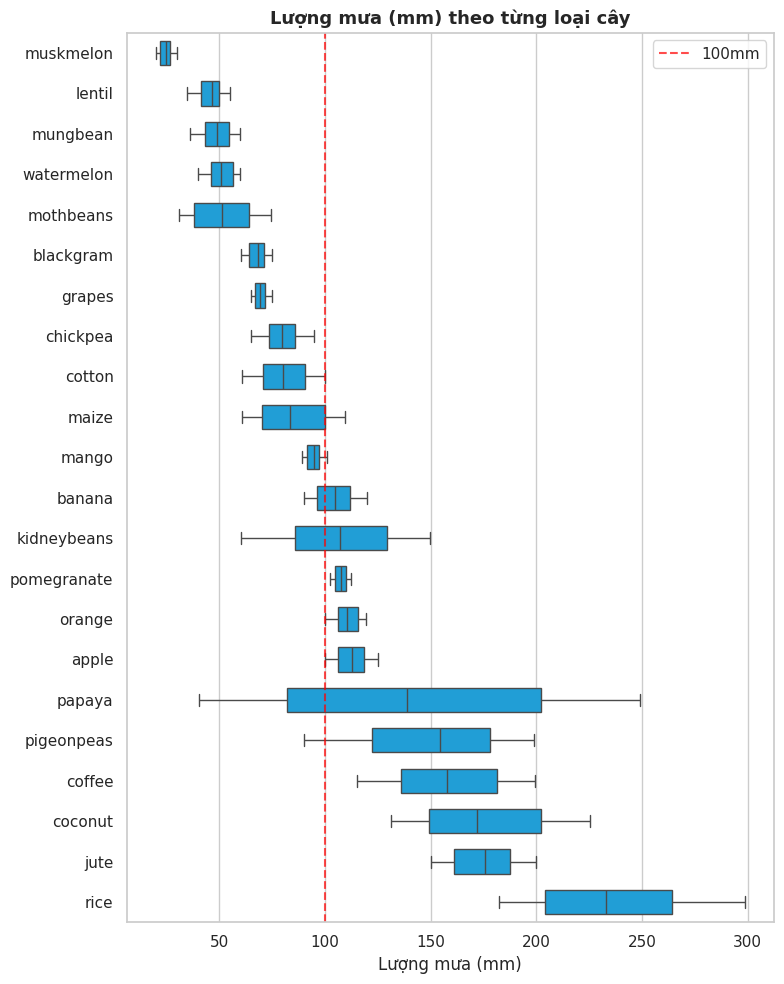

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))
order = df.groupby(TARGET)['rainfall'].median().sort_values().index
sns.boxplot(data=df, x='rainfall', y=TARGET, order=order, ax=ax, color='#03A9F4', width=0.6)
ax.set_title('Lượng mưa (mm) theo từng loại cây', fontweight='bold', fontsize=13)
ax.set_xlabel('Lượng mưa (mm)')
ax.set_ylabel('')
ax.axvline(x=100, color='red', linestyle='--', alpha=0.7, label='100mm')
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Cây cần mưa nhiều (>200mm):** Rice, Papaya, Coconut, Jute — nhóm nhiệt đới ẩm.
- **Cây cần mưa vừa (80–150mm):** Maize, Coffee, Banana.
- **Cây cần mưa ít (<80mm):** Cotton, Chickpea, Mungbean, Lentil — nhóm chịu hạn.
- Rainfall là **đặc trưng phân biệt môi trường mạnh nhất**.

**Hướng xử lý:**
- Thêm `log_rainfall = log(1 + rainfall)` do phân phối lệch mạnh — giúp mô hình tuyến tính học tốt hơn.

### 3.4 Trực Quan Hóa — Temperature, Humidity, pH theo Label

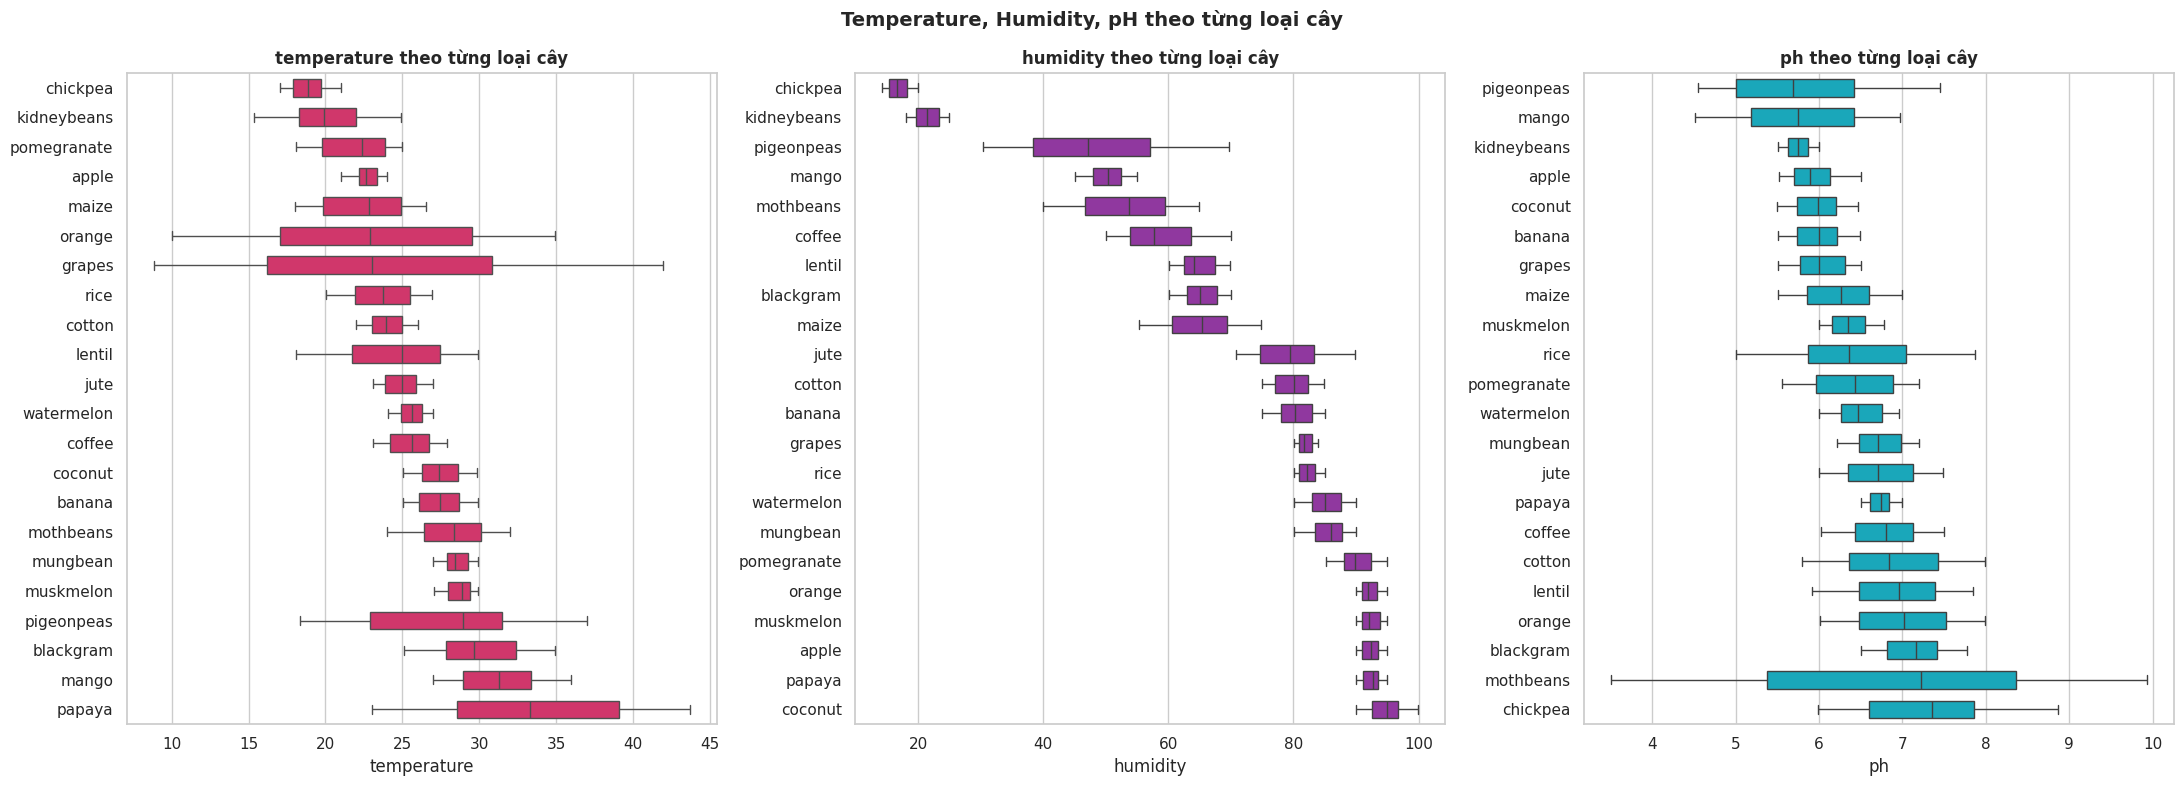

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, col, color in zip(axes, ['temperature','humidity','ph'], ['#E91E63','#9C27B0','#00BCD4']):
    order = df.groupby(TARGET)[col].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, color=color, width=0.6)
    ax.set_title(f'{col} theo từng loại cây', fontweight='bold')
    ax.set_ylabel('')
plt.suptitle('Temperature, Humidity, pH theo từng loại cây', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Temperature:** Apple, Grapes ưa mát (~15–22°C). Mango, Papaya ưa nóng (~30–35°C). Range rộng → phân biệt tốt.
- **Humidity:** Jute, Rice, Coconut ưa độ ẩm cao (>85%). Cotton, Chickpea ưa khô (~30–40%). Bimodal rõ rệt.
- **pH:** Grapes, Apple ưa pH thấp (~5.5). Chickpea, Mothbeans ưa pH cao hơn (~7.5–8). Range 3.5–9.9 → phân biệt được.

**Hướng xử lý:**
- Giữ nguyên cả 3 features, chỉ cần scaling.
- Thêm `temp_humidity = temperature × humidity` để nắm hiệu ứng kết hợp khí hậu.

### 3.5 Trực Quan Hóa — Heatmap Mean NPK theo Label

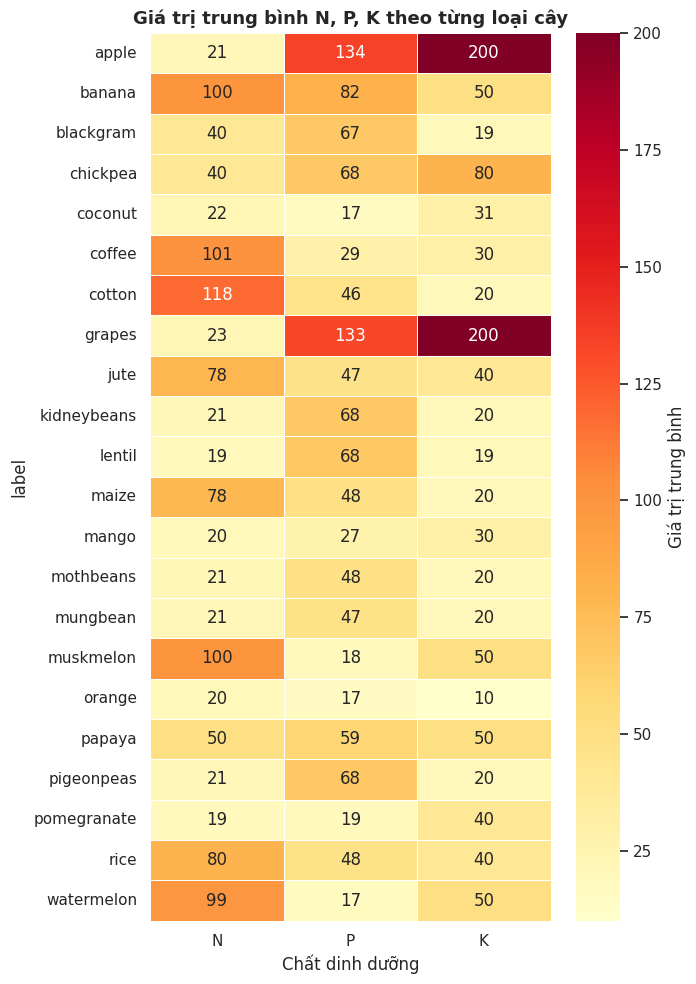

In [14]:
npk_mean = df.groupby(TARGET)[['N','P','K']].mean()
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(npk_mean, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Giá trị trung bình'})
ax.set_title('Giá trị trung bình N, P, K theo từng loại cây', fontweight='bold', fontsize=13)
ax.set_xlabel('Chất dinh dưỡng')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Rõ **2 nhóm đối lập**:
  - **N cao, P & K thấp:** Rice, Jute, Maize, Coffee — nhóm cây lương thực/công nghiệp chủ đạo.
  - **N thấp, P & K cao:** Chickpea, Lentil, Pigeonpeas, Kidneybeans — nhóm đậu đỗ (legumes).
- Pattern này rất rõ ràng → mô hình có thể học tốt từ NPK.

**Hướng xử lý:**
- Thêm các ratio features `N/P`, `N/K`, `P/K` để encode pattern tương đối giữa 3 chất dinh dưỡng.

---
## 4. Phân Tích Đa Biến (Multivariate)

Phân tích mối quan hệ **đồng thời nhiều features**.

### 4.1 Phân Tích Thống Kê — Ma Trận Tương Quan

In [15]:
corr = df[FEATURES].corr()
print("=== MA TRẬN TƯƠNG QUAN PEARSON ===")
print(corr.round(3))
print()
print("=== CÁC CẶP CÓ TƯƠNG QUAN CAO NHẤT (|r| > 0.1) ===")
pairs = corr.unstack().reset_index()
pairs.columns = ['Feature1', 'Feature2', 'Correlation']
pairs = pairs[pairs['Feature1'] < pairs['Feature2']].sort_values('Correlation', key=abs, ascending=False)
print(pairs.head(10).to_string(index=False))

=== MA TRẬN TƯƠNG QUAN PEARSON ===
                 N      P      K  temperature  humidity     ph  rainfall
N            1.000 -0.231 -0.141        0.027     0.191  0.097     0.059
P           -0.231  1.000  0.736       -0.128    -0.119 -0.138    -0.064
K           -0.141  0.736  1.000       -0.160     0.191 -0.170    -0.053
temperature  0.027 -0.128 -0.160        1.000     0.205 -0.018    -0.030
humidity     0.191 -0.119  0.191        0.205     1.000 -0.008     0.094
ph           0.097 -0.138 -0.170       -0.018    -0.008  1.000    -0.109
rainfall     0.059 -0.064 -0.053       -0.030     0.094 -0.109     1.000

=== CÁC CẶP CÓ TƯƠNG QUAN CAO NHẤT (|r| > 0.1) ===
Feature1    Feature2  Correlation
       K           P     0.736232
       N           P    -0.231460
humidity temperature     0.205320
       K    humidity     0.190859
       N    humidity     0.190688
       K          ph    -0.169503
       K temperature    -0.160387
       K           N    -0.140512
       P          ph   

### 4.2 Trực Quan Hóa — Heatmap Correlation

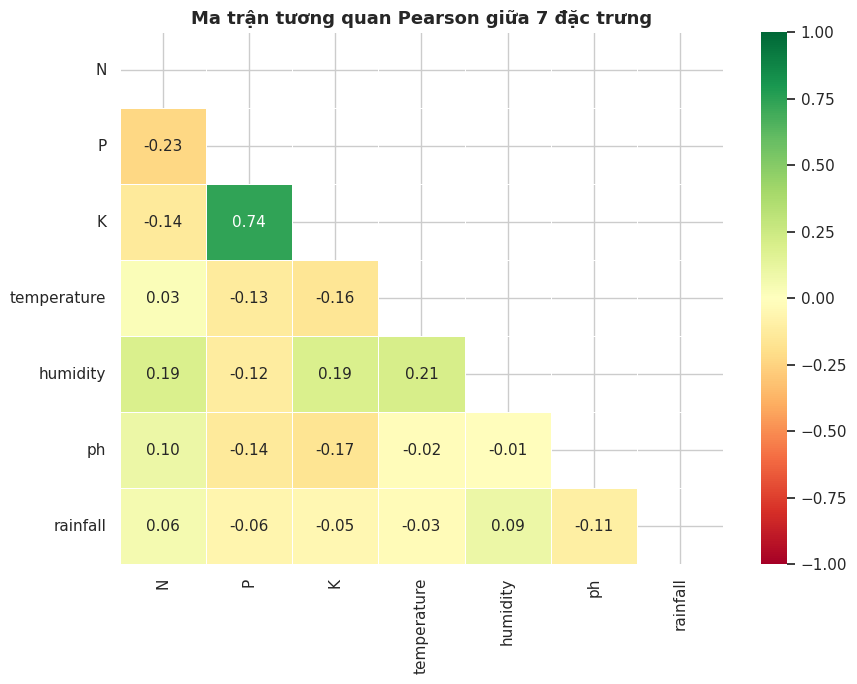

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size': 11}, vmin=-1, vmax=1)
ax.set_title('Ma trận tương quan Pearson giữa 7 đặc trưng', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Tất cả các cặp features có **|correlation| < 0.2** → không có multicollinearity đáng kể.
- Mỗi feature mang **thông tin độc lập**, không có feature nào là "thừa".
- Đây là điều kiện lý tưởng — tất cả 7 features đều có đóng góp riêng cho mô hình.

**Hướng xử lý:**
- **Giữ toàn bộ 7 features gốc**.
- Có thể thêm engineered features mà không lo bị redundancy/multicollinearity.

### 4.3 Trực Quan Hóa — Scatter Temperature × Rainfall

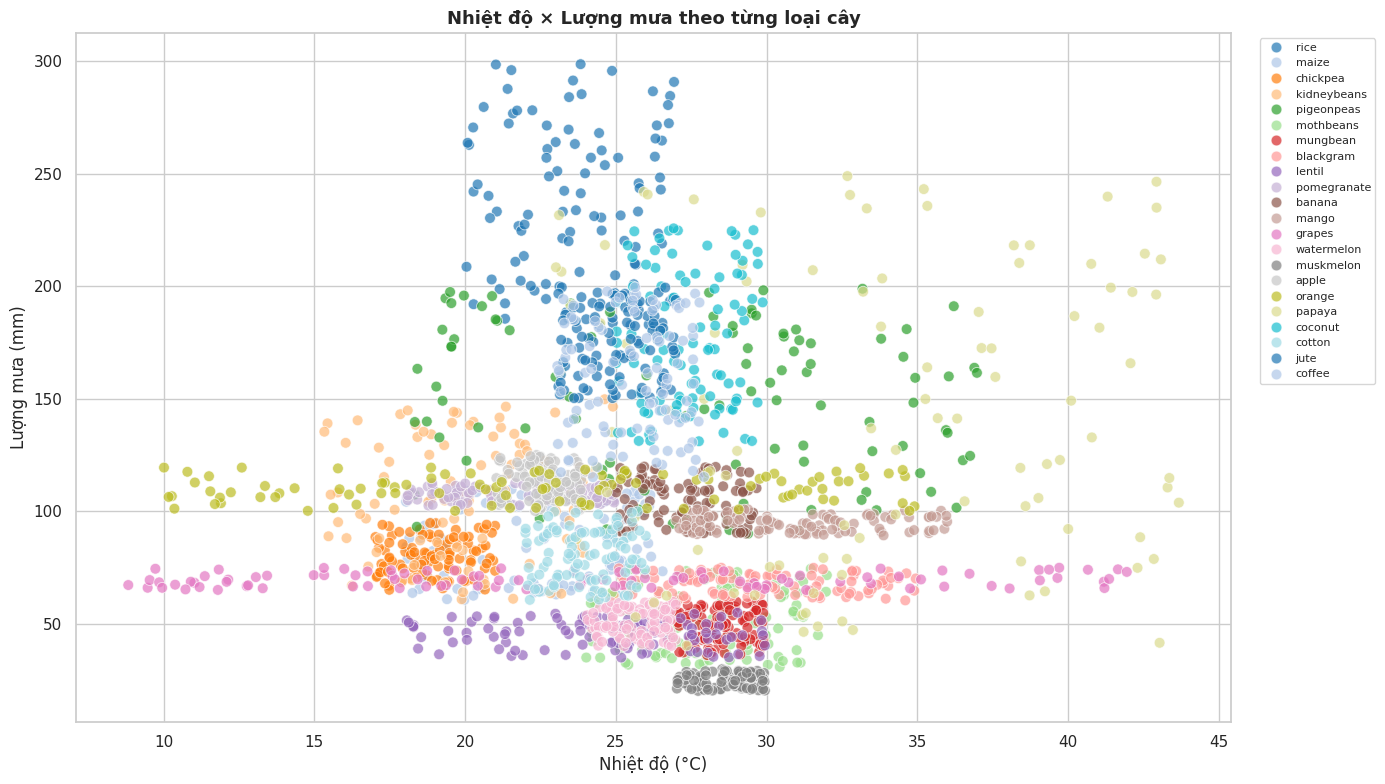

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))
palette = sns.color_palette('tab20', n_colors=22)
scatter = sns.scatterplot(data=df, x='temperature', y='rainfall',
                          hue=TARGET, palette=palette, ax=ax, alpha=0.7, s=60)
ax.set_title('Nhiệt độ × Lượng mưa theo từng loại cây', fontweight='bold', fontsize=13)
ax.set_xlabel('Nhiệt độ (°C)')
ax.set_ylabel('Lượng mưa (mm)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Nhiều loại cây hình thành **cụm rõ ràng** trong không gian 2D temperature × rainfall:
  - **Apple, Grapes**: Lạnh + mưa vừa (góc trái)
  - **Rice, Jute, Coconut**: Ấm + mưa nhiều (góc phải trên)
  - **Cotton, Chickpea, Mungbean**: Nóng + ít mưa (góc phải dưới)
- Một số cây **chồng lấn** nhau (Maize, Pigeonpeas) → cần thêm features NPK để phân biệt.

**Hướng xử lý:**
- Thêm `temp_humidity = temperature × humidity` để nắm bắt hiệu ứng kết hợp 2 yếu tố khí hậu.
- Kết hợp cả features dinh dưỡng + khí hậu trong mô hình.

### 4.4 Trực Quan Hóa — Scatter P × K

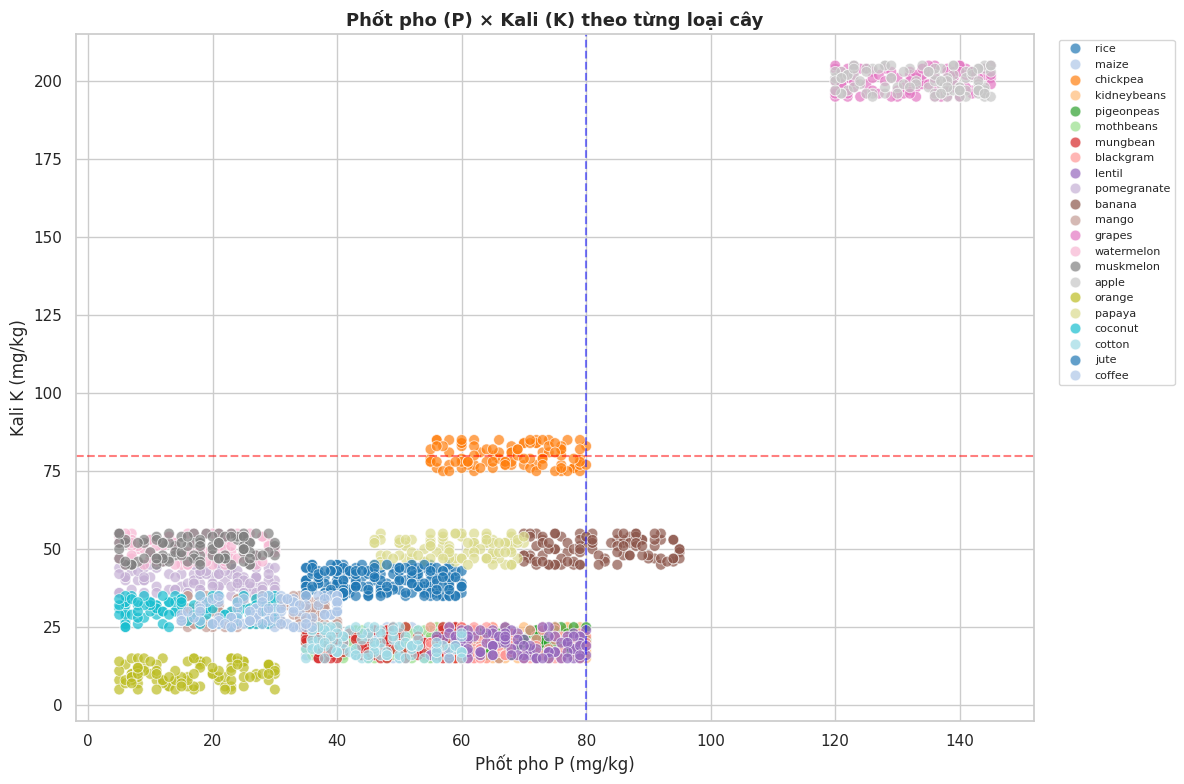

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('tab20', n_colors=22)
sns.scatterplot(data=df, x='P', y='K', hue=TARGET, palette=palette, ax=ax, alpha=0.7, s=60)
ax.set_title('Phốt pho (P) × Kali (K) theo từng loại cây', fontweight='bold', fontsize=13)
ax.set_xlabel('Phốt pho P (mg/kg)')
ax.set_ylabel('Kali K (mg/kg)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
# Vẽ vùng phân tách đậu đỗ
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='K=80')
ax.axvline(x=80, color='blue', linestyle='--', alpha=0.5, label='P=80')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Nhóm **đậu đỗ** (Chickpea, Lentil, Pigeonpeas, Kidneybeans, Mothbeans, Blackgram, Mungbean) **tách biệt hoàn toàn** ở góc P cao + K cao (P>80, K>80).
- Phần còn lại (20+ loại cây) tập trung ở P<80, K<80.
- Đây là ranh giới phân loại rõ nhất trong toàn bộ dataset.

**Hướng xử lý:**
- Thêm `ratio_p_k = P / (K + ε)` và `total_npk = N + P + K` để encode pattern nhóm đậu đỗ.

### 4.5 Trực Quan Hóa — Bubble Chart: Rainfall × Humidity × N/P/K

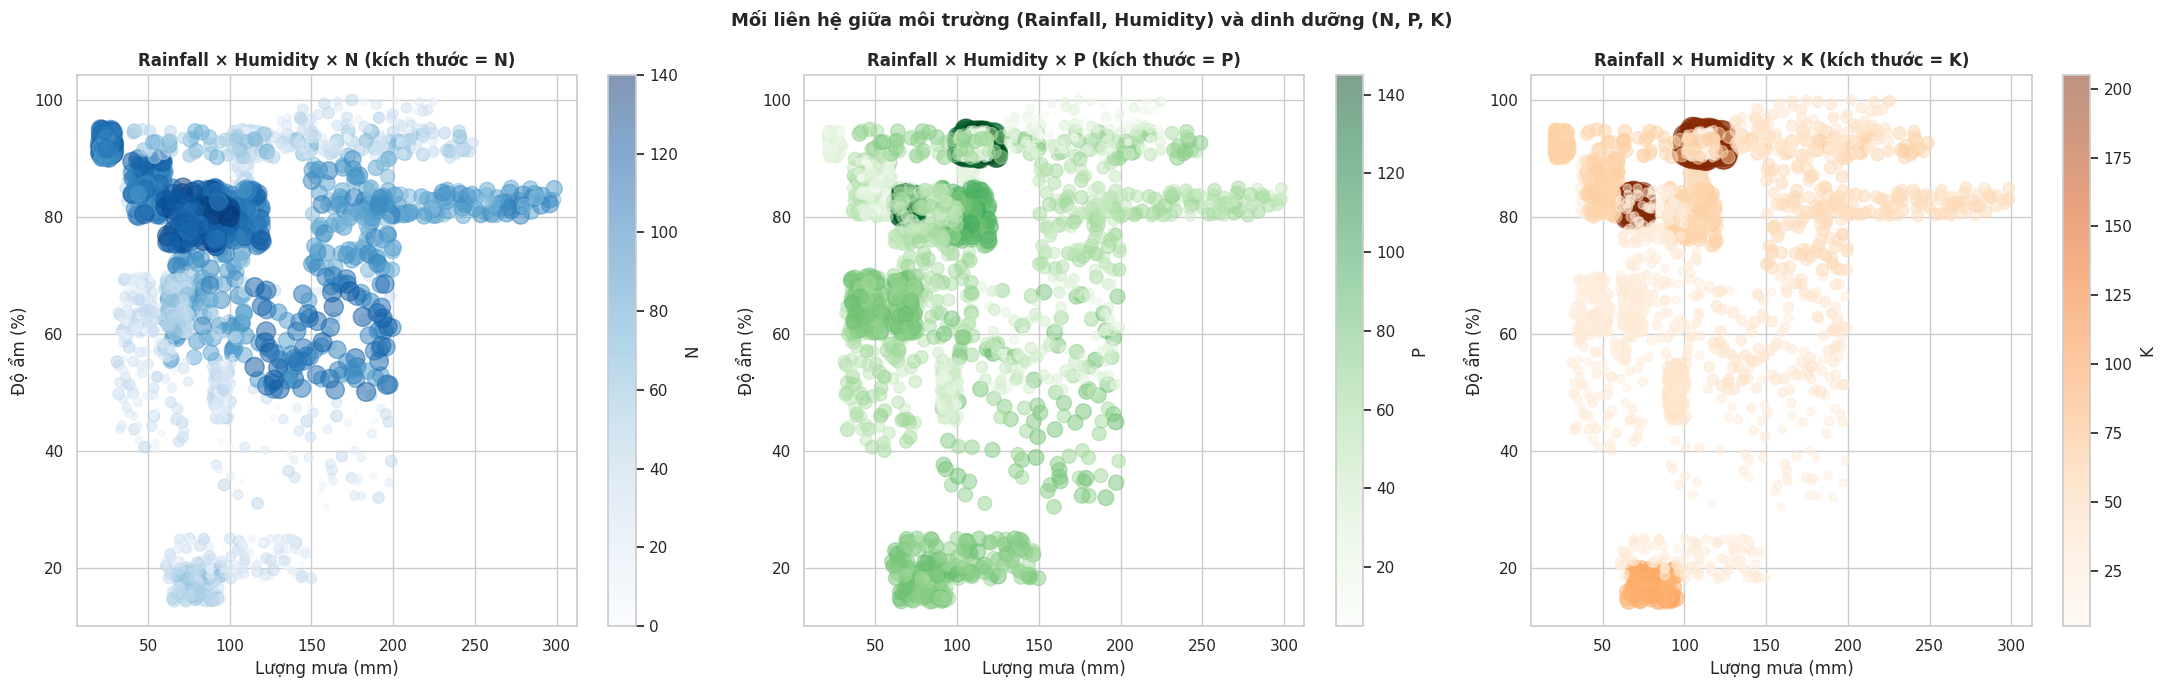

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
bubble_features = ['N', 'P', 'K']
colors_map = ['Blues', 'Greens', 'Oranges']
for ax, feat, cmap in zip(axes, bubble_features, colors_map):
    sc = ax.scatter(df['rainfall'], df['humidity'],
                    s=df[feat] * 1.5 + 10,
                    c=df[feat], cmap=cmap, alpha=0.5)
    plt.colorbar(sc, ax=ax, label=feat)
    ax.set_title(f'Rainfall × Humidity × {feat} (kích thước = {feat})', fontweight='bold')
    ax.set_xlabel('Lượng mưa (mm)')
    ax.set_ylabel('Độ ẩm (%)')
plt.suptitle('Mối liên hệ giữa môi trường (Rainfall, Humidity) và dinh dưỡng (N, P, K)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Rainfall cao + Humidity vừa** → N cao (bubble lớn, màu đậm) → nhóm Rice, Jute, Coffee.
- **Rainfall vừa + Humidity rất cao** → P & K cao đột biến → nhóm đậu đỗ.
- **Rainfall thấp + Humidity thấp** → N, P, K đều thấp → nhóm cây chịu hạn (Cotton, Chickpea...).
- Xác nhận: Cả 7 features đều **cần thiết và bổ trợ lẫn nhau**.

**Hướng xử lý:**
- Pipeline preprocessing cần **giữ toàn bộ 7 features gốc** + các engineered features đã đề xuất.

### 4.6 Trực Quan Hóa — Pair Plot (5 features quan trọng nhất)

Đang vẽ Pair Plot (có thể mất 30–60 giây)...


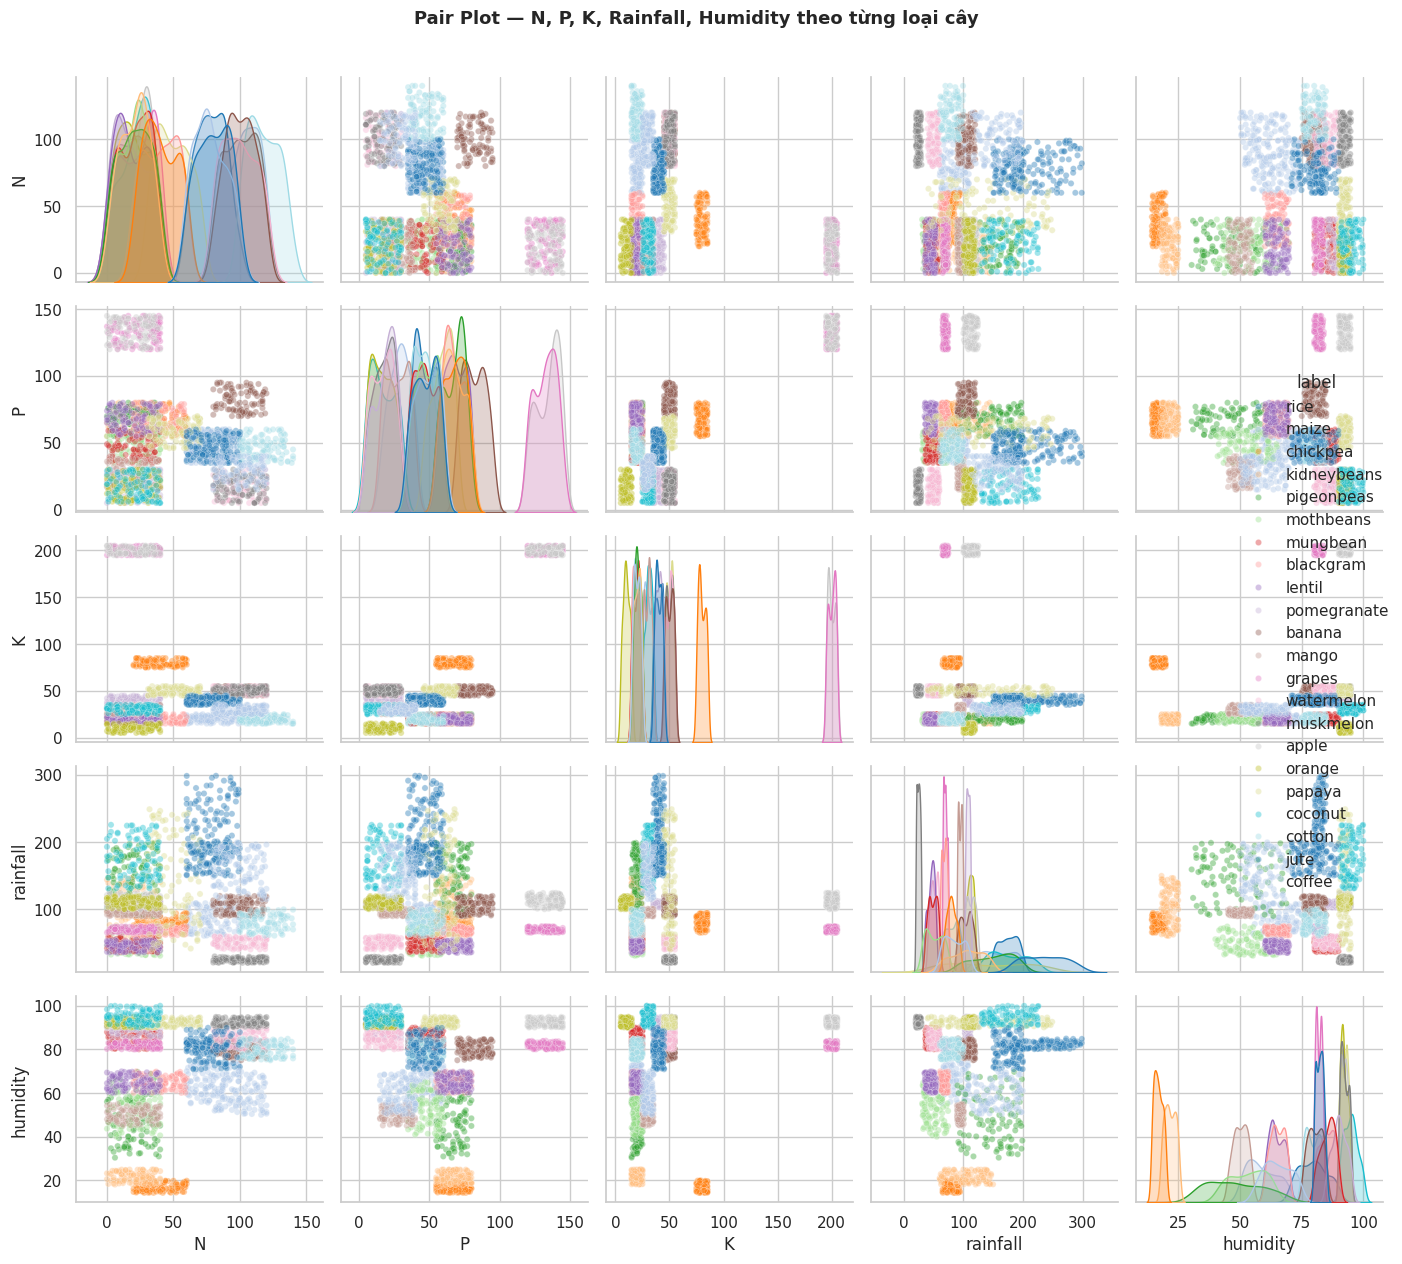

In [20]:
print("Đang vẽ Pair Plot (có thể mất 30–60 giây)...")
sample_df = df[['N', 'P', 'K', 'rainfall', 'humidity', TARGET]].copy()
g = sns.pairplot(sample_df, hue=TARGET, palette='tab20',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.figure.suptitle('Pair Plot — N, P, K, Rainfall, Humidity theo từng loại cây',
                   y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- Nhìn thấy rõ **cấu trúc phân cụm** của 22 loại cây trong không gian đa chiều.
- Cặp **P × K** và **N × Rainfall** tạo ra ranh giới phân loại **rõ nhất**.
- Có thể phân biệt nhiều nhóm cây mà **không cần overlap** → mô hình ML sẽ học tốt.
- Dự báo accuracy > 90% với mô hình phù hợp.

**Hướng xử lý:**
- Xác nhận chiến lược **feature engineering** đã đề ra là đúng hướng.
- Các mô hình dựa trên cây quyết định (Random Forest, XGBoost) sẽ đặc biệt hiệu quả với dataset này.

---
## 5. Tổng Kết EDA & Hướng Xử Lý Cho Preprocessing

| Quyết định | Lý do từ EDA |
|---|---|
| Giữ toàn bộ 7 features | Correlation thấp, mỗi feature mang thông tin độc lập |
| **RobustScaler** | Phân phối lệch, outlier tự nhiên → dùng median/IQR |
| **QuantileClipper [1%, 99%]** | Outlier là tự nhiên → giảm tác động cực biên, không xóa |
| **SimpleImputer(strategy='median')** | Phòng thủ — pipeline ổn định dù 0 missing values |
| **`total_npk = N + P + K`** | Pattern tổng NPK đặc trưng cho từng nhóm |
| **`ratio_n_p`, `ratio_n_k`, `ratio_p_k`** | Tỷ lệ tương đối giữa N, P, K quan trọng hơn giá trị tuyệt đối |
| **`temp_humidity = temperature × humidity`** | Interaction khí hậu phân biệt nhóm cây |
| **`log_rainfall = log(1 + rainfall)`** | Rainfall lệch phải mạnh → log-transform |
| **Stratified split** | Dataset cân bằng → `stratify=label` khi chia tập |
